In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ibrl.environments import NewcombEnvironment,DeathInDamascusEnvironment,AsymmetricDeathInDamascusEnvironment,CoordinationGameEnvironment
from ibrl.agents import InfraBayesianAgent
from ibrl.infrabayesian import WorldModel,AMeasure,Infradistribution,NewcombWorldModel
from ibrl.utils import sample_action
from ibrl.simulators import simulate

In [2]:
def simulate_environment(env, x, steps=1000):
    wm = NewcombWorldModel(env.reward_table)  # WM needs to know reward matrix
    m = AMeasure(wm.make_params(1))
    dist = Infradistribution([m],wm)
    agent = InfraBayesianAgent(
        num_actions=2,
        epsilon=0.,
        hypotheses=[dist],
        reward_function=wm.agent_reward_matrix(),
        policy_discretisation=5)

    optimal = []
    simulated = []
    action_rate = []
    optimal_rate = []
    for i,p in enumerate(x):
        env.predictor_accuracy = m.params.predictor_accuracy = p
        results = simulate(env, agent, {"num_steps": steps})
        optimal.append(results["optimal_reward"])
        simulated.append(results["average_reward"][0].mean())
        action_rate.append(results["probabilities"][0][:,1].mean())

        # Optimal action rate (BaseNewcombLikeEnvironment.get_optimal_reward)
        (a,b),(c,d) = env.reward_table.tolist()
        acc = env.predictor_accuracy
        A = acc*(a - c) + c
        C = (2*acc - 1)*(a + d - b - c)
        D = acc*(d - b) + b
        B = D - A - C
        optimal_rate.append(max(
            (A,0),
            (D,1),
            (A - B**2/(4*C), -B/(2*C)) if (C < 0 and 0 <= -B/(2*C) <= 1) else (float("-inf"),float("nan"))
        )[1])

    return optimal,simulated,action_rate,optimal_rate

In [3]:
steps = 1000
x = np.linspace(0.5, 1.0, 51)
optimal1,simulated1,rate1,optimal_rate1 = simulate_environment(NewcombEnvironment(boxA=1,boxB=10), x, steps)
optimal2,simulated2,rate2,optimal_rate2 = simulate_environment(DeathInDamascusEnvironment(), x, steps)
optimal3,simulated3,rate3,optimal_rate3 = simulate_environment(AsymmetricDeathInDamascusEnvironment(), x, steps)
optimal4,simulated4,rate4,optimal_rate4 = simulate_environment(CoordinationGameEnvironment(), x, steps)
optimal_rate2[0] = optimal_rate2[1] # Fix edge case for plotting

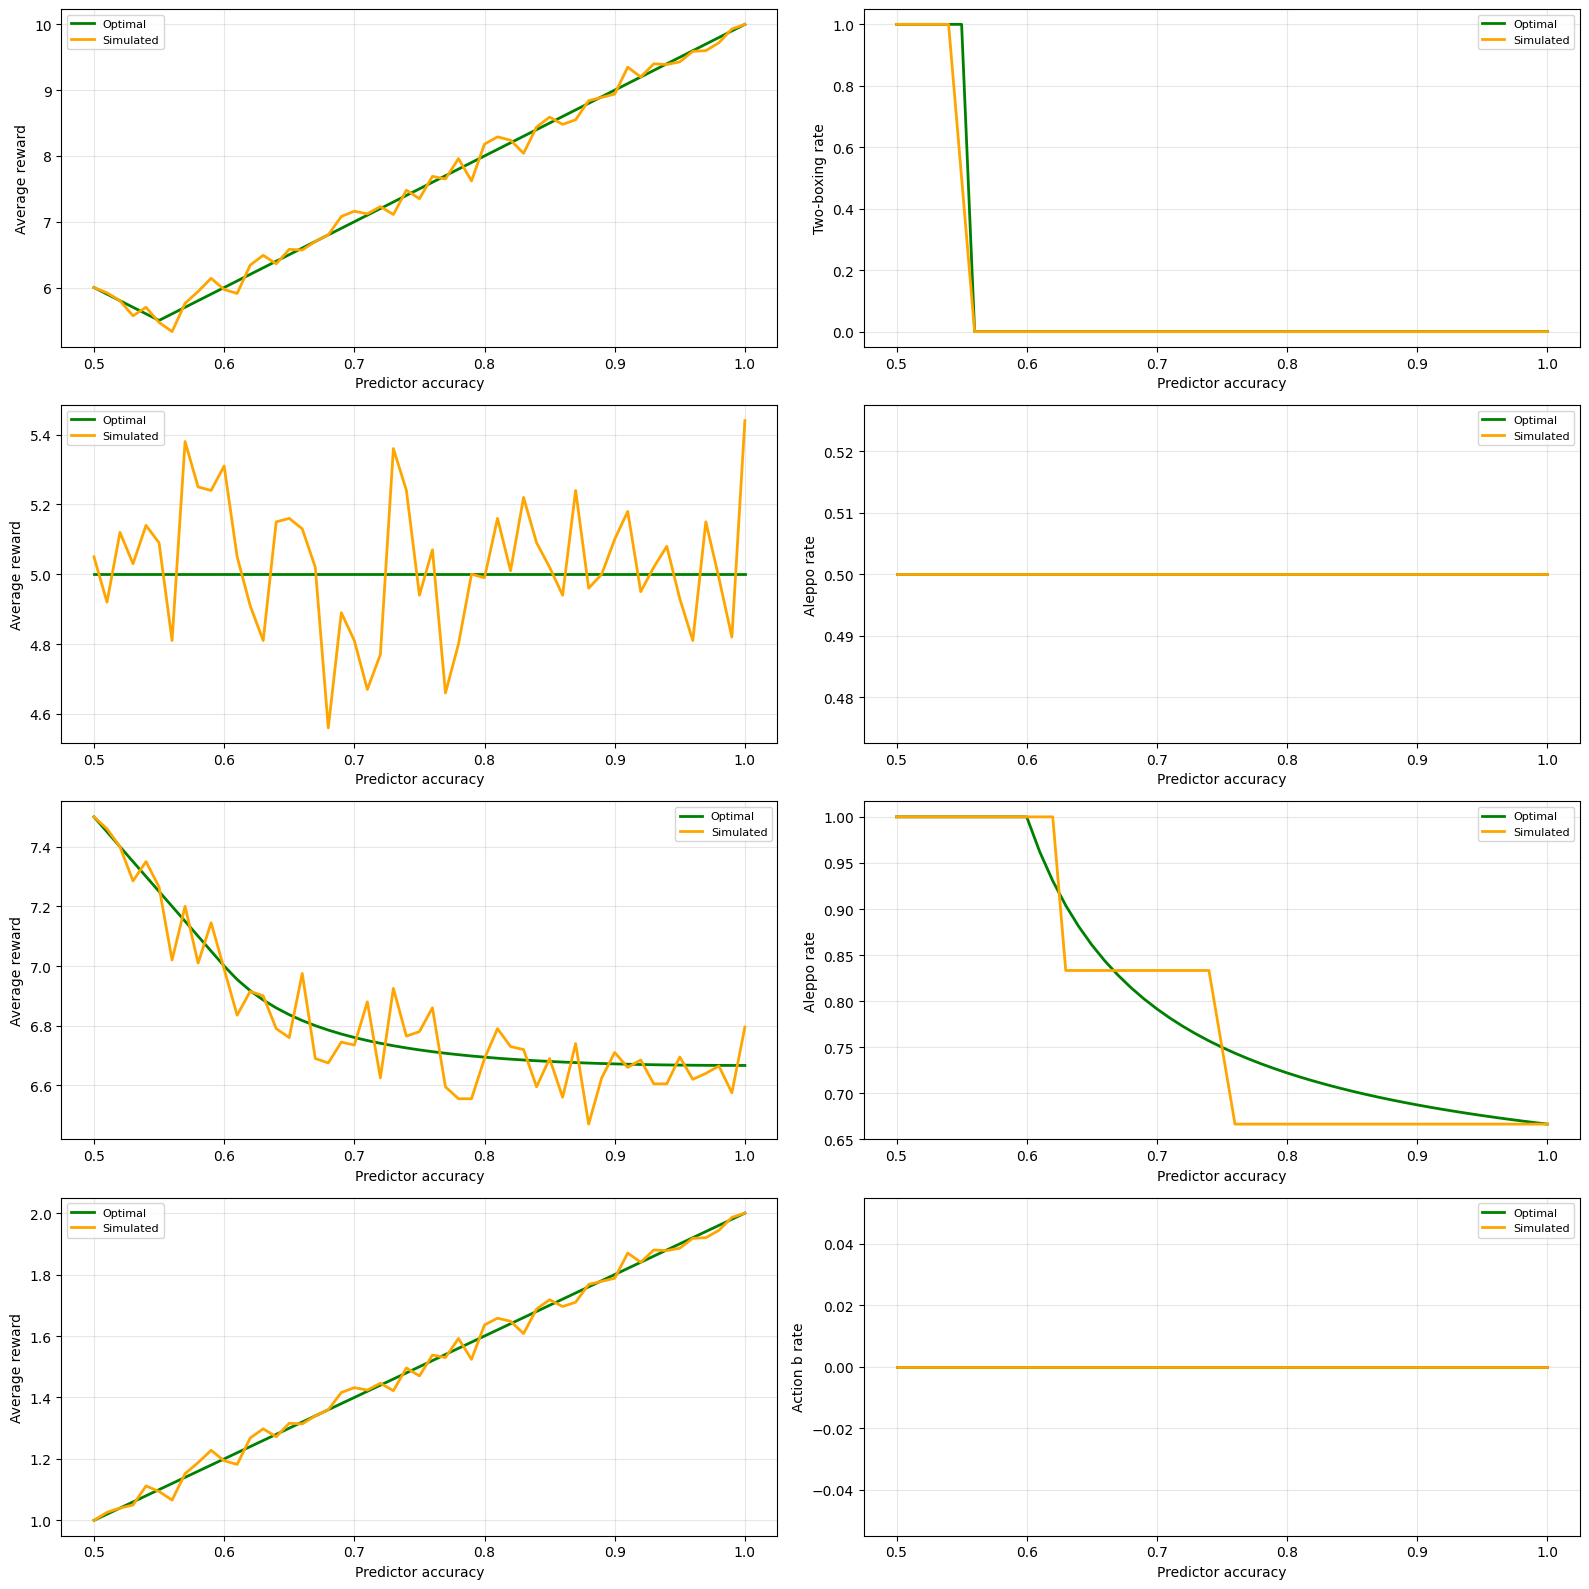

In [4]:
fig, axes = plt.subplots(4, 2, figsize=(16, 16))

for i,(label,optimal,simulated,rate,optimal_rate) in enumerate(zip(
    ["Two-boxing","Aleppo","Aleppo","Action b"],
    [optimal1,optimal2,optimal3,optimal4],
    [simulated1,simulated2,simulated3,simulated4],
    [rate1,rate2,rate3,rate4],
    [optimal_rate1,optimal_rate2,optimal_rate3,optimal_rate4])):

    ax = axes[i][0]
    ax.plot(x,optimal, linewidth=2, color="green", label="Optimal")
    ax.plot(x,simulated, linewidth=2, color="orange", label="Simulated")
    ax.set_xlabel("Predictor accuracy")
    ax.set_ylabel("Average reward")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax = axes[i][1]
    ax.plot(x,optimal_rate, linewidth=2, color="green", label="Optimal")
    ax.plot(x,rate, linewidth=2, color="orange", label="Simulated")
    ax.set_xlabel("Predictor accuracy")
    ax.set_ylabel(label+" rate")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()